In [43]:
# --------------------- Import Libraries ---------------------
import os
import sys
import yaml
from pathlib import Path

import scanpy as sc
import anndata as ad
import squidpy as sq
import seaborn as sns
import pandas as pd
import numpy as np
import networkx as nx
import scipy.sparse as sp
import matplotlib.pyplot as plt

import torch
import pytorch_lightning as pl
import torch_geometric.transforms as T
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader

from vqniche.utils.parse_test_configs import *
from vqniche.initializers.initialize import *
from vqniche.utils.metrics import *
from vqniche.utils.type_conversions import *

## Functions

### Initialize

In [31]:
@torch.no_grad()
def inference(model, infer_dataloader):    
    X = []
    H_pre_vq_conv = []
    H_vq = []
    Indices = []
    X_hat = []
    H_edge = []
    Labels_cell_type = []
    Labels_niche_type = []

    for batch in infer_dataloader:
        batch_size = batch.batch_size
        X.append(batch.x[:batch_size])
        Labels_cell_type.append(batch.y[:batch_size])
        Labels_niche_type.append(batch.y_niche_types[:batch_size])

        h_pre_vq_conv, \
        h_vq, \
        indices, \
        _, \
        codebook_embeddings, \
        h_node, \
        h_edge, \
        unnormalized_logits_batch = model(batch.x, batch.edge_index)

        H_pre_vq_conv.append(h_pre_vq_conv[:batch_size])
        H_vq.append(h_vq[:batch_size])
        Indices.append(indices[:batch_size])
        X_hat.append(h_node[:batch_size])
        H_edge.append(h_edge[:batch_size])

    X = torch.cat(X, dim=0)
    H_pre_vq_conv = torch.cat(H_pre_vq_conv, dim=0)
    H_vq = torch.cat(H_vq, dim=0)
    Indices = torch.cat(Indices, dim=0)
    X_hat = torch.cat(X_hat, dim=0)
    H_edge = torch.cat(H_edge, dim=0)
    Labels_cell_type = torch.cat(Labels_cell_type, dim=0)
    Labels_niche_type = torch.cat(Labels_niche_type, dim=0)
    
    return X, \
        Labels_cell_type, \
        Labels_niche_type, \
        H_pre_vq_conv, \
        H_vq, \
        Indices, \
        X_hat, \
        H_edge

In [32]:
def test(config: Dict):
    """
    Test a model on a single batch of data using the provided configuration.
    
    Parameters
    ----------
    - config: Dict
        A dictionary containing the configuration parameters for the training run.
    
    Returns
    -------
    - None
    """
    # --------------------- Determinism Settings ---------------------
    pl.seed_everything(config['experiment']['seed'])

    # --------------------- Load Adata ---------------------
    f = Path(config['dataset']['root_data_dir']) / 'silver' / config['dataset']['dataset_name'] / config['dataset']['adata_fname'][0]
    adata = sc.read_h5ad(f)

    # --------------------- Dataset ---------------------
    dataset_blob = initialize_dataset_blob(config)

    # --------------------- Databatch ---------------------
    data_batch = initialize_databatch(
                    config=config,
                    dataset_blob=dataset_blob,
                )
    
    # --------------------- Dataloader ---------------------
    datamodule_batch = initialize_datamodule(
                            config=config,
                            data=data_batch,
                        )

    # --------------------- Model ---------------------
    Model = set_model_class(config['model']['model_name'])
    model = Model.load_from_checkpoint(
        config['model']['model_ckpt'],
        map_location=torch.device('cpu')
    )
    
    # --------------------- Trainer ---------------------    
    trainer = pl.Trainer(
                    accelerator="cpu",
                    devices=1,
                    deterministic=True,
                    logger=False,
                    callbacks=False,
                    strategy='ddp_notebook',
                    max_epochs=config['trainer']['max_epochs'],
                    enable_checkpointing=False,
                    num_sanity_val_steps=0,
                    enable_progress_bar=False,
                    enable_model_summary=False,
                )
    
    # --------------------- Accuracy ---------------------
    # compute model accuracy on validation and test sets
    print("Computing Model Validation Accuracy...")
    trainer.validate(
        model=model,
        datamodule=datamodule_batch,
        verbose=True,
    )
    print("Computing Model Test Accuracy...")
    trainer.test(
        model=model,
        datamodule=datamodule_batch,
        verbose=True,
    )

    
    # --------------------- Inference on the full dataset ---------------------
    # return adata, dataset_blob, datamodule_batch, model, trainer
    X, \
    Labels_cell_type, \
    Labels_niche_type, \
    H_pre_vq_conv, \
    H_vq, \
    Indices, \
    X_hat, \
    H_edge = inference(model, datamodule_batch.infer_dataloader())
   
    return adata, \
        dataset_blob, \
        data_batch, \
        datamodule_batch, \
        model, \
        trainer, \
        X, \
        Labels_cell_type, \
        Labels_niche_type, \
        H_pre_vq_conv, \
        H_vq, \
        Indices, \
        X_hat, \
        H_edge

### Model Training

In [ ]:
def read_train_val_metrics(
        wandb_run_dir: Path = None,
    ) -> pd.DataFrame:
    """
    This function reads all metrics logged to output log file during each training epoch and returns them as a Pandas DataFrame.
    
    Parameters
    ----------
    wandb_run_dir : str | Path
        Path to the wandb run directory containing the output log file.
        
    Returns
    -------
    df: pd.DataFrame
        DataFrame containing all metrics logged during each training epoch.
        
    Notes:
    ------
    - This expects that the log file is named 'train_val_epoch_metrics.csv' and is located in the 'files' directory of the wandb run directory.
    - The log file is expected to have loss terms and accuracies as headings and their corresponding values as rows.
    - All other lines in the log file are ignored.
    - The metrics are various losses and accuracies logged during training and validation epochs.
    """
    logfile = wandb_run_dir / 'files' / 'train_val_epoch_metrics.csv'
    raw_df = pd.read_csv(logfile)

    # replace 'nan' strings with actual NaN values
    raw_df.replace('nan', np.nan, inplace=True)

    return raw_df

### Model Testing

In [ ]:
def build_embeddings(
        adata,
        model,
        datamodule_batch
    ):
    H_pre_vq_conv = []
    H_post_vq_conv = []
    Logits = []
    Labels = []

    for test_batch in datamodule_batch.test_dataloader():
        h_pre_vq_conv, \
        _, \
        _, \
        _, \
        codebook_embeddings, \
        _, \
        _, \
        h_post_vq_conv, \
        logits \
            = model.forward(
                    test_batch.x,
                    test_batch.edge_index
                    )
        H_pre_vq_conv.append(h_pre_vq_conv[:test_batch.batch_size])
        H_post_vq_conv.append(h_post_vq_conv[:test_batch.batch_size])
        Logits.append(logits[:test_batch.batch_size])
        Labels.append(test_batch.y[:test_batch.batch_size])

    adata.obsm['H_pre_vq_conv'] = torch.cat(H_pre_vq_conv, dim=0).detach().numpy()
    adata.obsm['H_post_vq_conv'] = torch.cat(H_post_vq_conv, dim=0).detach().numpy()
    adata.obsm['codebook_embeddings'] = codebook_embeddings.detach().numpy()
    adata.obsm['Logits'] = torch.cat(Logits, dim=0).detach().numpy()
    adata.obs['Labels'] = torch.cat(Labels, dim=0).detach().numpy()
    adata.obs['Labels'] = np.argmax(adata.obs['Labels'],axis=1).astype(str)
    
    return adata

### Plotting

In [ ]:
def plot_train_val_metrics(
        loss_df: pd.DataFrame,
        test_acc: float = None,
    ):
    """
    This function plots all metrics logged during training and validation epochs.
    
    Parameters
    ----------
    loss_df : pd.DataFrame
        DataFrame containing all metrics logged during each training epoch.
    test_acc : float
        Test accuracy of the model.
    
    Returns
    -------
    None
    """
    # Melt the dataframe to have a 'Mode' column for 'Train' and 'Val'
    df = loss_df.melt(id_vars=['epoch'], 
                        value_vars=['train_cross_entropy', 'val_cross_entropy', 
                                    'train_mse_attribute_reconstruction', 'val_mse_attribute_reconstruction', 
                                    'train_mse_adjacency_reconstruction', 'val_mse_adjacency_reconstruction', 
                                    'train_mse_commitment_loss', 'val_mse_commitment_loss', 
                                    'train_l2_codebook_loss', 'val_l2_codebook_loss', 
                                    'train_loss', 'val_loss'],
                        var_name='Loss Term', value_name='Value')

    # Create 'Mode' column
    df['Mode'] = df['Loss Term'].apply(lambda x: 'Train' if 'train' in x else 'Val')

    # Simplify 'Loss Term' column
    df['Loss Term'] = df['Loss Term'].apply(lambda x: x.replace('train_', '').replace('val_', ''))

    # Replace metric values with proper names
    metric_names = {
        'cross_entropy': 'Cross Entropy Loss',
        'mse_attribute_reconstruction': 'MSE Attr. Reconstr.',
        'mse_adjacency_reconstruction': 'MSE Adj. Reconstr.',
        'mse_commitment_loss': 'MSE Commit Loss',
        'l2_codebook_loss': 'L2 Codebook Loss',
        'loss': 'Total Loss'
    }

    df['Loss Term'] = df['Loss Term'].map(metric_names)

    # Create a column to indicate if the metric value is NaN
    df['isNaN'] = df['Value'].isna()

    # Group by 'Loss Term' and replace NaN with 1.1 * max value for each group
    df['Value'] = df.groupby('Loss Term')['Value'].transform(lambda x: x.fillna(1.1 * x.max()))
    display(df)
        
    loss_terms = df['Loss Term'].unique()

    fig, axes = plt.subplots(2, 3, figsize=(12,8))

    for ax, loss_term in zip(axes.flatten(), loss_terms):
        sns.lineplot(data=df[df['Loss Term'] == loss_term], x='epoch', y='Value', hue='Mode', style='isNaN', markers=True, dashes=False, ax=ax)

        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

        ax.set_xlabel('Epoch')
        ax.set_ylabel(loss_term)
        ax.set_title(loss_term)
    
    fig.legend(
        handles,
        labels,
        bbox_to_anchor=(0.5,-0.08),
        loc='lower center',
        ncol=2,
    )

    fig.suptitle(f"Test Accuracy: {test_acc:.2f}", fontsize=16)

    plt.tight_layout()
    plt.show()

In [ ]:
# Scanpy processing for UMAP
def compute_umap(
        adata,
        embedding_key='h_pre_vq_conv',
        label_key='cell_type',
    ):
    sc.pp.neighbors(adata, n_neighbors=25, n_pcs=40)  # Compute neighborhood graph
    # sc.pp.pca(adata)  # Compute PCA
    # sc.pl.pca(adata, color='labels', show=False)
    sc.tl.umap(adata)  # Compute UMAP
    sc.pl.umap(adata,color='labels',show=False)
    plt.show()

## Analysis

### sss2-1b_1p

In [33]:
wandb_run_dir = "/lustre/scratch126/cellgen/team361/am84/VQNiche/reproducibility/logs/sss2-1b_1p/standalone/batch=[0]/spatial_n_neighs_4/wandb/offline-run-20250405_110926-jzulygdt"
model_ckpt = None

config_fname = Path(wandb_run_dir) / 'files' / 'config.yaml'
with open(config_fname, "r") as f:
    config = yaml.safe_load(f)

# Set model checkpoint file name
if model_ckpt:
    config['model']['model_ckpt'] = model_ckpt
else:
    config['model']['model_ckpt'] = find_best_checkpoint(wandb_run_dir)
  
# adata, dataset_blob, datamodule_batch, model, trainer = test(config)

adata, \
dataset_blob, \
data_batch, \
datamodule_batch, \
model, \
trainer, \
X, \
Labels_cell_type, \
Labels_niche_type, \
H_pre_vq_conv, \
H_vq, \
Indices, \
X_hat, \
H_edge = test(config)

Seed set to 0
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores


Best checkpoint found: epoch=9-val_acc=0.93.ckpt
Batch ID(s): [0]
Data Batch: DataBatch(y_cell_types=[10000, 8], y_niche_types=[10000, 8], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[10000, 1105], y=[10000, 8], edge_index=[2, 50000], num_features=1105, num_classes=8, num_nodes=10000, num_edges=[1], train_mask=[10000], val_mask=[10000], test_mask=[10000], batch=[10000], ptr=[2])
Number of Tissue Sections: 1
Loader Name: NeighborLoader
Num Workers: 1
Loader Name: NeighborLoader
Loader Class: <class 'torch_geometric.loader.neighbor_loader.NeighborLoader'>
Loader Params: {'batch_size': 1024}
Sampler Name: NeighborSampler
Sampler Class: <class 'torch_geometric.sampler.neighbor_sampler.NeighborSampler'>
Sampler Params: {'num_neighbors': [25, 10]}
Sample Neighbors for Inference: False
Setting the following loss terms as criterion for training:
Loss function: cross_entropy
Loss function: mse_attribute_reconstruction
Loss function: mse_commit_loss
Loss function:

HPU available: False, using: 0 HPUs


Computing Model Validation Accuracy...


/lustre/scratch126/cellgen/team361/am84/conda/envs/vqniche-reproducibility/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
----------------------------------------------------------------------------------------------------
distributed_backend=gloo
All distributed processes registered. Starting with 1 processes
----------------------------------------------------------------------------------------------------



┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Validate metric          ┃           DataLoader 0           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│             val_acc              │        0.9340000152587891        │
│        val_cross_entropy         │        0.3363382816314697        │
│             val_loss             │        19.24533462524414         │
│ val_mse_attribute_reconstruction │       0.15541328489780426        │
│        val_mse_code_loss         │        9.376791000366211         │
│       val_mse_commit_loss        │        9.376791000366211         │
└──────────────────────────────────┴──────────────────────────────────┘

Computing Model Test Accuracy...


Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
----------------------------------------------------------------------------------------------------
distributed_backend=gloo
All distributed processes registered. Starting with 1 processes
----------------------------------------------------------------------------------------------------



┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9369999766349792     │
└───────────────────────────┴───────────────────────────┘

In [34]:
print("Building Original Graph...")
G = nx.from_numpy_array(
        edge_index_to_adjacency_tensor(
            data_batch.edge_index
        ).numpy()
    )

print("Building Reconstructed Graph...")
G_hat = nx.from_numpy_array(
        build_reconstructed_adjacency_matrix(
            H_edge
        ).numpy()
    )


Building Original Graph...
Building Reconstructed Graph...


In [47]:
def new_compute_mmd(
        input_distribution: np.ndarray,
        target_distribution: np.ndarray,
        method: Literal['gaussian_tv'] = 'gaussian_tv',
        sigma: Optional[float] = 1.0
    ) -> float:
    """
    Compute the Maximum Mean Discrepancy (MMD) between two distributions.

    Parameters
    ----------
    - input_distribution: numpy.ndarray
        The input distribution.
        Dimensions: (num_nodes)
    - target_distribution: numpy.ndarray
        The target distribution.
        Dimensions: (num_nodes)
    - method: Literal['gaussian_tv']
        The method to use to compute the discrepancy.
        Options: 'gaussian_tv'
    - sigma: float
        The bandwidth of the Gaussian kernel.

    Returns
    -------
    - discrepancy: float
        The discrepancy between the two distributions.

    References
    ----------
    - https://github.com/KarolisMart/SPECTRE/blob/main/util/dist_helper.py
    """
    assert np.isclose(input_distribution.sum(), 1.0)
    assert np.isclose(target_distribution.sum(), 1.0)

    input_support_size = input_distribution.size
    target_support_size = target_distribution.size
    support_size = max(input_support_size, target_support_size)
    print(f"{input_support_size=} | {target_support_size=} | {support_size=}")

    # pad the input distribution with zeros if it is smaller than the target distribution
    if input_support_size < support_size:
        input_distribution = np.hstack((input_distribution, [0.0] * (support_size - input_support_size)))

    # pad the target distribution with zeros if it is smaller than the input distribution
    if target_support_size < support_size:
        target_distribution = np.hstack((target_distribution, [0.0] * (support_size - target_support_size)))

    if method == 'gaussian_tv':
        distance = np.abs(input_distribution - target_distribution).sum() / 2.0
        discrepancy = np.exp(-distance / (2.0 * sigma ** 2))

    return discrepancy


In [49]:
dd = np.array(nx.degree_histogram(G))
dd = dd / dd.sum()
print(dd)
dd_hat = np.array(nx.degree_histogram(G_hat))
dd_hat = dd_hat / dd_hat.sum()
print(dd_hat)

print(dd.sum(), dd_hat.sum(), dd.shape, dd_hat.shape)

new_compute_mmd(dd, dd_hat)

[0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 4.430e-01
 3.337e-01 1.586e-01 5.010e-02 1.320e-02 1.200e-03 2.000e-04]
[0.     0.     0.     ... 0.     0.     0.0015]
0.9999999999999999 1.0 (13,) (4620,)
input_support_size=13 | target_support_size=4620 | support_size=4620


0.6065306597126334

In [ ]:
loss_df = read_train_val_metrics(wandb_run_dir)
display(loss_df)

In [59]:
indices_list = []
node_ids = []
loaders = [datamodule_batch.train_dataloader(), datamodule_batch.val_dataloader(), datamodule_batch.test_dataloader()]

for loader in loaders:
        for batch in loader:
                h_pre_vq_conv, \
                h_vq, \
                indices, \
                dist, \
                codebook_embeddings, \
                h_node, \
                h_edge, \
                h_post_vq_conv, \
                unnormalized_logits_batch \
                        = model(
                                batch.x,
                                batch.edge_index,
                        )
                indices_list.append(indices[:batch.batch_size])
                node_ids.append(batch.input_id)

indices = torch.cat(indices_list, dim=0)
node_ids = torch.cat(node_ids, dim=0)
print(f"Indices shape: {indices.shape}")
print(f"Node IDs shape: {node_ids.shape}")
indices = indices[torch.argsort(node_ids)]
print(f"Indices shape: {indices.shape}")
print(f"Node IDs shape: {node_ids.shape}")

Indices shape: torch.Size([10000])
Node IDs shape: torch.Size([10000])
Indices shape: torch.Size([10000])
Node IDs shape: torch.Size([10000])


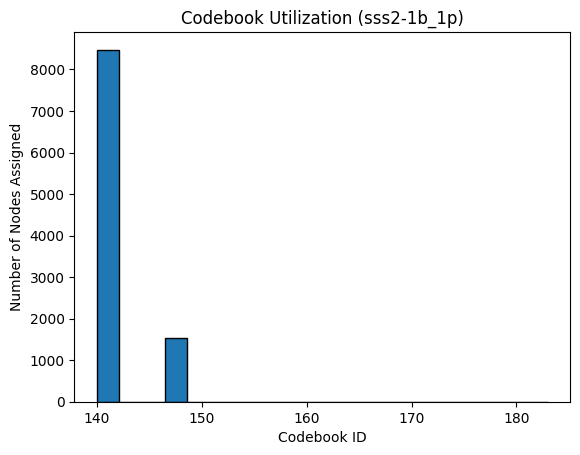

In [61]:
plt.hist(indices.numpy(), bins=20, edgecolor='black')
plt.xlabel('Codebook ID')
plt.ylabel('Number of Nodes Assigned')
plt.title('Codebook Utilization (sss2-1b_1p)')
plt.show()

In [42]:
print(node_ids)

tensor([   2,    3,    4,  ..., 9932, 9955, 9976])


In [ ]:
# Get the edge index tensor
edge_index = data_batch.edge_index

# Create a dictionary to store neighbors for each node
neighbors_dict = {i: [] for i in range(data_batch.num_nodes)}

# Populate the dictionary with neighbors
for src, dst in edge_index.t().tolist():
    neighbors_dict[src].append(dst)

# Print the neighbors for each node
for node_id, neighbors in neighbors_dict.items():
    print(f"Node {node_id} has neighbors: {neighbors}")

In [ ]:
test_acc = trainer.test(
    model=model,
    datamodule=datamodule_batch,
)[0]['test_acc']

In [ ]:
plot_train_val_metrics(
    loss_df,
    test_acc,
    wandb_run_dir
)

In [ ]:
adata = build_embeddings(
            adata=adata,
            model=model,
            datamodule_batch=datamodule_batch
        )

In [ ]:
compute_umap(adata)

### xhs1000-39b_1p (batch 11)

In [32]:
dataset_name = 'xhs1000-39b_1p'
batch_id = 11
adata_fname = f'adata_batch{batch_id}.h5ad'

config_fname = '/lustre/scratch126/cellgen/team361/am84/VQNiche/reproducibility/config/train_model/xhs1000-39b-batch11_1p_vq_graphsage.yaml'

# set path to wandb run directory
wandb_run_id = 'offline-run-20250303_142417-6tnfmggl'
# set path to model checkpoint within wandb run directory that you want to load
model_ckpt_fname = 'epoch=6-val_acc=0.96.ckpt'

# set path to wandb run directory
wandb_run_id = 'offline-run-20250303_143251-hvfj79k3'
# set path to model checkpoint within wandb run directory that you want to load
model_ckpt_fname = 'epoch=7-val_acc=0.94.ckpt'

# set path to wandb run directory
wandb_run_id = 'offline-run-20250303_192332-33fs5ymb'
# set path to model checkpoint within wandb run directory that you want to load
model_ckpt_fname = 'epoch=3-val_acc=0.96.ckpt'



In [33]:
config, \
adata, \
dataset_blob, \
data_batch, \
datamodule_batch, \
model, \
trainer = initialize_everything(
        config_fname,
        wandb_run_id,
        model_ckpt_fname,
    )

Batch ID: tensor([11])
Loader Name: NeighborLoader
Num Workers: 1
Loader Name: NeighborLoader
Loader Class: <class 'torch_geometric.loader.neighbor_loader.NeighborLoader'>
Loader Params: {'batch_size': 128}
Sampler Name: NeighborSampler
Sampler Class: <class 'torch_geometric.sampler.neighbor_sampler.NeighborSampler'>
Sampler Params: {'num_neighbors': [25, 10]}
Use Full Graph for Inference: True
Setting the following loss terms as criterion for training:
Loss function: cross_entropy
Loss function: mse_attribute_reconstruction
Loss function: mse_adjacency_reconstruction
Loss function: mse_commitment_loss
Loss function: l2_codebook_loss
Initializing the pre-VQ Graph Convolution module.
Graph Convolution applied from 4948 to 4948 across 1 layer(s).
Initializing the decoder module for node attributes.
Initializing the decoder module for the adjacency matrix.
Initializing the post-VQ Graph Convolution module.
Graph Convolution applied from 4948 to 32 across 1 layer(s).


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [34]:
indices_list = []
node_ids = []
loaders = [datamodule_batch.train_dataloader(), datamodule_batch.val_dataloader(), datamodule_batch.test_dataloader()]

for loader in loaders:
        for batch in loader:
                h_pre_vq_conv, \
                h_vq, \
                indices, \
                dist, \
                codebook_embeddings, \
                h_node, \
                h_edge, \
                h_post_vq_conv, \
                unnormalized_logits_batch \
                        = model(
                                batch.x,
                                batch.edge_index,
                        )
                indices_list.append(indices[:batch.batch_size])
                # print(indices)
                node_ids.append(batch.input_id)

indices = torch.cat(indices_list, dim=0)
node_ids = torch.cat(node_ids, dim=0)
indices = indices[torch.argsort(node_ids)]
print(indices.shape)
print(node_ids.shape)

torch.Size([17832])
torch.Size([17832])


In [35]:
unique_indices = torch.unique(indices)
unique_count = unique_indices.size(0)
print(f"Number of unique indices: {unique_count}")

Number of unique indices: 11


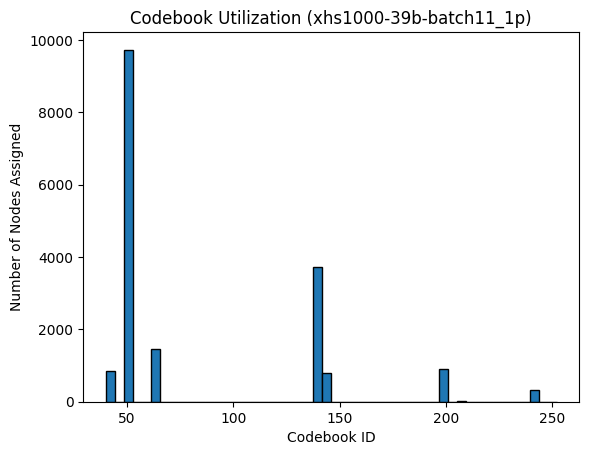

In [36]:
plt.hist(indices.numpy(), bins=50, edgecolor='black')
plt.xlabel('Codebook ID')
plt.ylabel('Number of Nodes Assigned')
plt.title('Codebook Utilization (xhs1000-39b-batch11_1p)')
plt.show()

In [ ]:
test_acc = trainer.test(
    model=model,
    datamodule=datamodule_batch,
)[0]['test_acc']

In [ ]:
loss_df = read_train_val_metrics(wandb_run_dir)
display(loss_df)

In [ ]:
plot_train_val_metrics(
    loss_df,
    test_acc,
    wandb_run_dir
)

In [ ]:
adata = build_embeddings(
            adata=adata,
            model=model,
            datamodule_batch=datamodule_batch
        )

In [ ]:
compute_umap(adata)

### xhs1000-39b_1p (batch 1 and 2)

In [39]:
dataset_name = 'xhs1000-39b_1p'
batch_id = [1,2]
# adata_fname = 'sim1_1105fts_10000locs.h5ad'

# set path to config file
config_fname = '/lustre/scratch126/cellgen/team361/am84/VQNiche/reproducibility/config/train_model/xhs1000-39b-batch1-2_1p_vq_graphsage.yaml'

# set wandb run id
# wandb_run_id = 'offline-run-20250219_113534-qp20ccoe'

# set model checkpoint filename
# model_ckpt_fname = 'epoch=8-val_acc=0.80.ckpt'

In [40]:
# --------------------- Load Config ---------------------
# Read parameters from config file
with open(config_fname, "r") as f:
    config = yaml.safe_load(f)

# # --------------------- Load AnnData ---------------------
# f = config['dataset']['root_data_dir'] / 'silver' / config['dataset']['dataset_name'] / config['dataset']['adata_fname']
# adata = sc.read_h5ad(f)

# --------------------- Dataset ---------------------
dataset_blob = initialize_dataset_blob(config)

# load PyG data object corresponding to batch_idx (e.g. 0 -> AnnData batch0)
# NOTE: sss2-1b_1p is 1-indexed, while others are 0-indexed
batch_idx = config['dataset']['batch_idx']
data_batch = dataset_blob[batch_idx]
print(f"Batch ID: {data_batch.batch}")


Batch ID: tensor([0, 1])


In [38]:
data_batch

Data(y_cell_type=[17832, 41], y_niche_type=[17832, 15], cell_id=[17832], dataset_id=1000, tissue='skin', species='homo_sapiens', batch=[1], x=[17832, 4948], y=[17832, 41], edge_index=[2, 89160], num_features=4948, num_classes=41, num_nodes=17832, num_edges=89160, train_mask=[17832], val_mask=[17832], test_mask=[17832])

In [65]:
print(dataset_blob[1].num_nodes, dataset_blob[1].batch)
print(dataset_blob[2].num_nodes, dataset_blob[2].batch)

8532 tensor([1])
15566 tensor([2])


In [59]:
d = DataLoader(
                [data for data in data_batch],
                batch_size=1,
                shuffle=False,
                num_workers=0,
                pin_memory=True,
                drop_last=False,
            ).collate_fn([data for data in data_batch])
print(d)

DataBatch(y_cell_type=[24098, 41], y_niche_type=[24098, 15], cell_id=[2], dataset_id=[2], tissue=[2], species=[2], batch=[24098], x=[24098, 4948], y=[24098, 41], edge_index=[2, 120490], num_features=[2], num_classes=[2], num_nodes=24098, num_edges=[2], train_mask=[24098], val_mask=[24098], test_mask=[24098], ptr=[3])


In [62]:
dm = initialize_datamodule(
                        config=config,
                        data=d,
                    )
N = 0
for tr_b in dm.train_dataloader():
    print(tr_b)
    N += tr_b.input_id.size(0)


Loader Name: NeighborLoader
Num Workers: 1
Loader Name: NeighborLoader
Loader Class: <class 'torch_geometric.loader.neighbor_loader.NeighborLoader'>
Loader Params: {'batch_size': 32}
Sampler Name: NeighborSampler
Sampler Class: <class 'torch_geometric.sampler.neighbor_sampler.NeighborSampler'>
Sampler Params: {'num_neighbors': [25, 10]}
Use Full Graph for Inference: True
Data(x=[130, 4948], edge_index=[2, 451], y=[130, 41], train_mask=[130], val_mask=[130], test_mask=[130], y_niche_type=[130, 15], y_cell_type=[130, 41], n_id=[130], e_id=[451], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[32], batch_size=32)
Data(x=[187, 4948], edge_index=[2, 567], y=[187, 41], train_mask=[187], val_mask=[187], test_mask=[187], y_niche_type=[187, 15], y_cell_type=[187, 41], n_id=[187], e_id=[567], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[32], batch_size=32)
Data(x=[182, 4948], edge_index=[2, 497], y=[182, 41], train_mask=[182], val_mask=[182], test_mask=[182], y_niche_type=[182

In [63]:
print(d.train_mask.sum(), N)

tensor(19278) 19278


In [49]:
d.batch

tensor([0, 0, 0,  ..., 1, 1, 1])

In [41]:
print(d.num_features, d.num_classes, d.num_nodes, d.num_edges, d.batch_size)

4948 tensor([41, 41]) 24098 tensor([42660, 77830]) 2


In [47]:
d[0][0]

KeyError: 0

In [13]:
for data in data_batch:
    print(data)

Data(y_cell_type=[8532, 41], y_niche_type=[8532, 15], cell_id=[8532], dataset_id=1000, tissue='skin', species='homo_sapiens', batch=[1], x=[8532, 4948], y=[8532, 41], edge_index=[2, 42660], num_features=4948, num_classes=41, num_nodes=8532, num_edges=42660, train_mask=[8532], val_mask=[8532], test_mask=[8532])
Data(y_cell_type=[15566, 41], y_niche_type=[15566, 15], cell_id=[15566], dataset_id=1000, tissue='skin', species='homo_sapiens', batch=[1], x=[15566, 4948], y=[15566, 41], edge_index=[2, 77830], num_features=4948, num_classes=41, num_nodes=15566, num_edges=77830, train_mask=[15566], val_mask=[15566], test_mask=[15566])


In [8]:
print(type(dataset_blob), type(data_batch), type(dataset_blob[0]))

<class 'vqniche.dataset.in_memory_dataset_blob.InMemoryDatasetBlob'> <class 'vqniche.dataset.in_memory_dataset_blob.InMemoryDatasetBlob'> <class 'torch_geometric.data.data.Data'>


In [30]:
for data in data_batch:
    print(data)
    print(data.train_mask)
    print(data.batch)
    print(data.train_mask.sum())
    print(data.val_mask.sum())
    print(data.test_mask.sum())
    print(data.num_nodes)
    print(data.num_features)
    print(data.num_classes) 

Data(y_cell_type=[8532, 41], y_niche_type=[8532, 15], cell_id=[8532], dataset_id=1000, tissue='skin', species='homo_sapiens', batch=[1], x=[8532, 4948], y=[8532, 41], edge_index=[2, 42660], num_features=4948, num_classes=41, num_nodes=8532, num_edges=42660, train_mask=[8532], val_mask=[8532], test_mask=[8532])
tensor([ True, False,  True,  ...,  True,  True,  True])
tensor([1])
tensor(6826)
tensor(853)
tensor(853)
8532
4948
41
Data(y_cell_type=[15566, 41], y_niche_type=[15566, 15], cell_id=[15566], dataset_id=1000, tissue='skin', species='homo_sapiens', batch=[1], x=[15566, 4948], y=[15566, 41], edge_index=[2, 77830], num_features=4948, num_classes=41, num_nodes=15566, num_edges=77830, train_mask=[15566], val_mask=[15566], test_mask=[15566])
tensor([ True,  True,  True,  ...,  True, False, False])
tensor([2])
tensor(12452)
tensor(1557)
tensor(1557)
15566
4948
41


In [56]:
loader = DataLoader(data_batch, batch_size=len(data_batch), shuffle=False)
for batch in loader:
    print(batch)
    print(batch.cell_id)
    print(batch.train_mask.sum())
    print(batch.val_mask.sum())
    print(batch.test_mask.sum())
    print(batch.num_nodes)
    print(batch.num_edges)
    print(batch.num_features)
    print(batch.num_classes)
    print(batch.num_graphs)

DataBatch(y_cell_type=[24098, 41], y_niche_type=[24098, 15], cell_id=[2], dataset_id=[2], tissue=[2], species=[2], batch=[24098], x=[24098, 4948], y=[24098, 41], edge_index=[2, 120490], num_features=[2], num_classes=[2], num_nodes=24098, num_edges=[2], train_mask=[24098], val_mask=[24098], test_mask=[24098], ptr=[3])
[['1000_batch1_0', '1000_batch1_1', '1000_batch1_2', '1000_batch1_3', '1000_batch1_4', '1000_batch1_5', '1000_batch1_6', '1000_batch1_7', '1000_batch1_8', '1000_batch1_9', '1000_batch1_10', '1000_batch1_11', '1000_batch1_12', '1000_batch1_13', '1000_batch1_14', '1000_batch1_15', '1000_batch1_16', '1000_batch1_17', '1000_batch1_18', '1000_batch1_19', '1000_batch1_20', '1000_batch1_21', '1000_batch1_22', '1000_batch1_23', '1000_batch1_24', '1000_batch1_25', '1000_batch1_26', '1000_batch1_27', '1000_batch1_28', '1000_batch1_29', '1000_batch1_30', '1000_batch1_31', '1000_batch1_32', '1000_batch1_33', '1000_batch1_34', '1000_batch1_35', '1000_batch1_36', '1000_batch1_37', '1000

In [ ]:
config, \
adata, \
data_batch, \
datamodule_batch, \
model, \
trainer = initialize_everything(
        config_fname,
        adata_fname,
        wandb_run_id,
        model_ckpt_fname
    )